# Bank Marketing Dataset

In [1]:
import lightgbm as lgb
import json
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import random
import pprint
import seaborn as sns
import shap
import xgboost as xgb
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials, space_eval
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, PredefinedSplit, StratifiedKFold, cross_validate, learning_curve, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from scipy.stats import randint, uniform
import time

%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 150)
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

## Reusable Workflow Functions

### Pre-processing for classical models

In [2]:
# ---------------------------------------
# 1. FEATURE ENGINEERING
# ---------------------------------------

def feature_engineering(df):
    df = df.copy()

    # Target
    df["y"] = df["y"].map({"yes": 1, "no": 0})

    # Basic engineered features
    df["campaign_clipped"] = df["campaign"].clip(upper=10)
    df["was_contacted_before"] = (df["pdays"] != 999).astype(int)
    df["contact_bin"] = (df["contact"] == "cellular").astype(int)

    # Remove leakage
    df = df.drop(columns=["duration", "pdays", "campaign", "default", "contact"])

    # Ordinal month
    month_map = {
        "jan":1, "feb":2, "mar":3, "apr":4, "may":5, "jun":6,
        "jul":7, "aug":8, "sep":9, "oct":10, "nov":11, "dec":12
    }
    df["month_ord"] = df["month"].map(month_map)

    
    # Ordinal day of week
    dow_map = {"mon":1, "tue":2, "wed":3, "thu":4, "fri":5}
    df["dow_ord"] = df["day_of_week"].map(dow_map)

    # --- Interaction feature 1: month × euribor3m ---
    df["month_euribor3m"] = df["month_ord"] * df["euribor3m"]

    # --- Interaction feature 2: month × nr.employed ---
    df["month_nr_employed"] = df["month_ord"] * df["nr.employed"]

    # --- Interaction feature 3: job × education ---
    df["job_education"] = df["job"] + "_" + df["education"]

    return df

# ---------------------------------------
# 2. TIME-BASED SPLIT
# ---------------------------------------

def split_by_month(df):
    val_months = ["sep", "oct", "nov", "dec"]
    train_df = df[~df["month"].isin(val_months)].copy()
    val_df = df[df["month"].isin(val_months)].copy()
    return train_df, val_df


# ---------------------------------------
# 3. PREPROCESSING FOR LOGREG / KNN / DT
# ---------------------------------------

def preprocess_for_classical_models(df, target_col="y"):
    df = feature_engineering(df)
    train_df, val_df = split_by_month(df)

    X_train = train_df.drop(columns=[target_col])
    y_train = train_df[target_col]

    X_val = val_df.drop(columns=[target_col])
    y_val = val_df[target_col]

    # Identify column types
    numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()
    categorical_cols = X_train.select_dtypes(include="object").columns.tolist()

    # Preprocessing pipeline
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols)
        ]
    )

    return X_train, y_train, X_val, y_val, preprocessor

### Pre-processing for boosting

In [3]:
# -----------------------------
# 1. FEATURE ENGINEERING
# -----------------------------

def feature_engineering(df):
    df = df.copy()

    # Target
    df["y"] = df["y"].map({"yes": 1, "no": 0})

    # Clip campaign
    df["campaign_clipped"] = df["campaign"].clip(upper=10)

    # Was contacted before
    df["was_contacted_before"] = (df["pdays"] != 999).astype(int)

    # Contact channel binary
    df["contact_bin"] = (df["contact"] == "cellular").astype(int)

    # Remove leakage
    df = df.drop(columns=["duration", "pdays", "campaign", "default", "contact"])

    # Month ordinal
    month_map = {
        "jan":1, "feb":2, "mar":3, "apr":4, "may":5, "jun":6,
        "jul":7, "aug":8, "sep":9, "oct":10, "nov":11, "dec":12
    }
    df["month_ord"] = df["month"].map(month_map)

    # Day of week ordinal
    dow_map = {"mon":1, "tue":2, "wed":3, "thu":4, "fri":5}
    df["dow_ord"] = df["day_of_week"].map(dow_map)

    # Interaction features
    df["month_euribor3m"] = df["month_ord"] * df["euribor3m"]
    df["month_nr_employed"] = df["month_ord"] * df["nr.employed"]
    df["job_education"] = df["job"] + "_" + df["education"]

    # -------------------------
    # GLOBAL CATEGORY VOCABULARY
    # -------------------------
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].astype("category")

    return df

# -----------------------------
# 2. TIME-BASED SPLIT
# -----------------------------

def split_by_month(df):
    val_months = ["sep", "oct", "nov", "dec"]
    train_df = df[~df["month"].isin(val_months)].copy()
    val_df = df[df["month"].isin(val_months)].copy()
    return train_df, val_df


# -----------------------------
# 3. PREPARE XGBOOST INPUTS
# -----------------------------

def prepare_for_xgboost(train_df, val_df, target_col="y"):
    X_train = train_df.drop(columns=[target_col])
    y_train = train_df[target_col]

    X_val = val_df.drop(columns=[target_col])
    y_val = val_df[target_col]

    return X_train, y_train, X_val, y_val

# -----------------------------
# 4. FULL PREPROCESS PIPELINE
# -----------------------------

def preprocess_data_boosting(df):
    df = feature_engineering(df)
    train_df, val_df = split_by_month(df)
    return prepare_for_xgboost(train_df, val_df)

### Model tuning fundctions

In [4]:
def objective_rf(params):
    params['n_estimators'] = int(params['n_estimators'])
    params['max_depth'] = int(params['max_depth'])
    params['min_samples_split'] = int(params['min_samples_split'])
    params['min_samples_leaf'] = int(params['min_samples_leaf'])

    rf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        **params,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))])

    rf.fit(X_train_classical, y_train_classical)
    preds = rf.predict(X_val_classical)
    f1 = f1_score(y_val_classical, preds)

    return {'loss': -f1, 'status': STATUS_OK}

space_rf = {
    'n_estimators': hp.quniform('n_estimators', 200, 400, 50),
    'max_depth': hp.quniform('max_depth', 4, 10, 1),
    'min_samples_split': hp.quniform('min_samples_split', 2, 10, 1),
    'min_samples_leaf': hp.quniform('min_samples_leaf', 1, 10, 1),
    'max_features': hp.choice('max_features', ['sqrt', 'log2', None]),
    'bootstrap': hp.choice('bootstrap', [True, False]),
    'criterion': hp.choice('criterion', ['gini', 'entropy', 'log_loss'])
}

In [5]:
def objective_xgb(params):
    clf = xgb.XGBClassifier(
        n_estimators=int(params['n_estimators']),
        learning_rate=params['learning_rate'],
        max_depth=int(params['max_depth']),
        min_child_weight=int(params['min_child_weight']),
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        gamma=params['gamma'],
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        scale_pos_weight=params['scale_pos_weight'],
        enable_categorical=True,
        missing=np.nan,
        tree_method="hist",
        early_stopping_rounds=10,
        random_state=42
    )

    clf.fit(
        X_train_bst,
        y_train_bst,
        eval_set=[(X_val_bst, y_val_bst)],
        verbose=False
    )

    preds = clf.predict(X_val_bst)
    f1 = f1_score(y_val_bst, preds)

    return {'loss': -f1, 'status': STATUS_OK}

space_xgb = {
    "n_estimators": hp.quniform("n_estimators", 200, 400, 25),
    "learning_rate": hp.uniform("learning_rate", 0.01, 0.08),
    "max_depth": hp.quniform("max_depth", 3, 5, 1),
    "min_child_weight": hp.quniform("min_child_weight", 3, 6, 1),
    "subsample": hp.uniform("subsample", 0.6, 0.8),
    "colsample_bytree": hp.uniform("colsample_bytree", 0.65, 0.7),
    "gamma": hp.uniform("gamma", 1, 3),
    "reg_alpha": hp.uniform("reg_alpha", 4, 6),
    "reg_lambda": hp.uniform("reg_lambda", 5, 6),
    "scale_pos_weight": hp.choice("scale_pos_weight", [3, 3.25, 3.5])
}

In [6]:
def random_search_xgb(param_dist, n_iter=30):
    best_f1 = -1
    best_params = None

    for i in range(n_iter):
        # Sample parameters
        params = {
            "n_estimators": random.randint(200, 500),
            "learning_rate": random.uniform(0.01, 0.2),
            "max_depth": random.randint(3, 5),
            "min_child_weight": random.randint(3, 9),
            "subsample": random.uniform(0.6, 0.7),
            "colsample_bytree": random.uniform(0.65, 0.7),
            "gamma": random.uniform(1, 3),
            "reg_alpha": random.uniform(3, 5),
            "reg_lambda": random.uniform(5, 7),
            "scale_pos_weight": random.choice([3, 3.5, 4])
        }
        
        model = xgb.XGBClassifier(
            **params,
            enable_categorical=True,
            tree_method="hist",
            missing=np.nan,
            random_state=42
        )

        model.fit(X_train_bst, y_train_bst, eval_set=[(X_val_bst, y_val_bst)], verbose=False)

        preds = model.predict(X_val_bst)
        f1 = f1_score(y_val_bst, preds)

        if f1 > best_f1:
            best_f1 = f1
            best_params = params

    return best_params, best_f1

### Model evaluation function

In [7]:
pd.set_option('display.max_colwidth', None)

def collect_model_results(models, preds_train, preds_val, y_train, y_val):
    """
    Collect evaluation metrics and hyperparameters for multiple models
    using precomputed predictions.
    
    Parameters
    ----------
    models : dict
        {"Model name": fitted_model}
    preds_train : dict
        {"Model name": y_train_pred}
    preds_val : dict
        {"Model name": y_val_pred}
    y_train, y_val : arrays
        True labels
    
    Returns
    -------
    DataFrame with metrics + hyperparameters
    """
    
    results = []

    for name, model in models.items():
        y_train_pred = preds_train[name]
        y_val_pred = preds_val[name]

        precision_train = round(precision_score(y_train, y_train_pred), 2)
        recall_train = round(recall_score(y_train, y_train_pred), 2)
        f1_train = round(f1_score(y_train, y_train_pred), 2)

        precision_val = round(precision_score(y_val, y_val_pred), 2)
        recall_val = round(recall_score(y_val, y_val_pred), 2)
        f1_val = round(f1_score(y_val, y_val_pred), 2)

        if isinstance(model, Pipeline):
            params = model.named_steps["model"].get_params()
        else:
            params = model.get_params()

        params_str = pprint.pformat(params, indent=1, width=80)

        results.append({
            "Model": name,
            "F1 (train)": f1_train,
            "F1 (val)": f1_val,
            "Recall (train)": recall_train,
            "Recall (val)": recall_val,
            "Precision (train)": precision_train,
            "Precision (val)": precision_val,
            "Hyperparameters": params_str
        })

    return pd.DataFrame(results)

In [8]:
def confusion_components(y_true, y_pred, model_name="Model"):
    TP = np.sum((y_pred == 1) & (y_true == 1))
    TN = np.sum((y_pred == 0) & (y_true == 0))
    FP = np.sum((y_pred == 1) & (y_true == 0))
    FN = np.sum((y_pred == 0) & (y_true == 1))

    total = len(y_true)

    print(f"{model_name} – Confusion Components")
    print(f"  TP (correct positives):   {TP}")
    print(f"  TN (correct negatives):   {TN}")
    print(f"  FP (false positives):     {FP}")
    print(f"  FN (false negatives):     {FN}")
    print(f"  Total samples:            {total}")
    print("-" * 50)

## Data Ingestion

In [9]:
raw_df = pd.read_csv('data/bank-additional-full.csv', sep=';')

In [10]:
raw_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Data transformation

In [11]:
X_train_classical, y_train_classical, X_val_classical, y_val_classical, preprocessor = preprocess_for_classical_models(raw_df)

In [12]:
X_train_bst, y_train_bst, X_val_bst, y_val_bst = preprocess_data_boosting(raw_df)

## Model Development

### Logistic regression

In [13]:
logreg = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(class_weight='balanced', penalty='l2', C=0.001, solver='liblinear', max_iter=500))
])

logreg.fit(X_train_classical, y_train_classical)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'previous',
                                                   'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed',
                                                   'campaign_clipped',
                                                   'was_contacted_before',
                                                   'contact_bin', 'month_ord',
                                                   'dow_ord', 'month_euribor3m',
                                                   'month_nr_employed']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  [])])),
                ('model',
                 LogisticRegression(C=0.001, class_weight='balanced',
                                    max_iter=500, solver='liblinear'))])

In [14]:
preds_train_logreg = logreg.predict(X_train_classical)
preds_val_logreg = logreg.predict(X_val_classical)

print(classification_report(y_train_classical, preds_train_logreg))
print(classification_report(y_val_classical, preds_val_logreg))

              precision    recall  f1-score   support

           0       0.95      0.73      0.83     32053
           1       0.22      0.68      0.33      3564

    accuracy                           0.73     35617
   macro avg       0.59      0.70      0.58     35617
weighted avg       0.88      0.73      0.78     35617

              precision    recall  f1-score   support

           0       0.94      0.76      0.84      4495
           1       0.44      0.79      0.57      1076

    accuracy                           0.77      5571
   macro avg       0.69      0.77      0.70      5571
weighted avg       0.84      0.77      0.79      5571



### KNN

In [15]:
knn = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=10))
])

knn.fit(X_train_classical, y_train_classical)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'previous',
                                                   'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed',
                                                   'campaign_clipped',
                                                   'was_contacted_before',
                                                   'contact_bin', 'month_ord',
                                                   'dow_ord', 'month_euribor3m',
                                                   'month_nr_employed']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  [])])),
                ('model', KNeighborsClassifier(n_neighbors=10))])

In [16]:
preds_train_knn = knn.predict(X_train_classical)
preds_val_knn = knn.predict(X_val_classical)

print(classification_report(y_train_classical, preds_train_knn))
print(classification_report(y_val_classical, preds_val_knn))

              precision    recall  f1-score   support

           0       0.92      0.99      0.95     32053
           1       0.71      0.25      0.37      3564

    accuracy                           0.91     35617
   macro avg       0.82      0.62      0.66     35617
weighted avg       0.90      0.91      0.90     35617

              precision    recall  f1-score   support

           0       0.85      0.95      0.90      4495
           1       0.61      0.31      0.41      1076

    accuracy                           0.83      5571
   macro avg       0.73      0.63      0.66      5571
weighted avg       0.81      0.83      0.81      5571



### Decision Tree Classifier

In [17]:
dt = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=4))
])

dt.fit(X_train_classical, y_train_classical)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'previous',
                                                   'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed',
                                                   'campaign_clipped',
                                                   'was_contacted_before',
                                                   'contact_bin', 'month_ord',
                                                   'dow_ord', 'month_euribor3m',
                                                   'month_nr_employed']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  [])])),
                ('model',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=4,
                                        random_state=42))])

In [18]:
preds_train_dt = dt.predict(X_train_classical)
preds_val_dt = dt.predict(X_val_classical)

print(classification_report(y_train_classical, preds_train_dt))
print(classification_report(y_val_classical, preds_val_dt))

              precision    recall  f1-score   support

           0       0.95      0.86      0.90     32053
           1       0.31      0.58      0.40      3564

    accuracy                           0.83     35617
   macro avg       0.63      0.72      0.65     35617
weighted avg       0.88      0.83      0.85     35617

              precision    recall  f1-score   support

           0       0.57      0.00      0.00      4495
           1       0.19      1.00      0.32      1076

    accuracy                           0.19      5571
   macro avg       0.38      0.50      0.16      5571
weighted avg       0.50      0.19      0.06      5571



### Random Forest Classifier

In [19]:
rf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=250,
        max_depth=5,
        min_samples_split=5,
        min_samples_leaf=3,
        random_state=42
    ))
])

rf.fit(X_train_classical, y_train_classical)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'previous',
                                                   'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed',
                                                   'campaign_clipped',
                                                   'was_contacted_before',
                                                   'contact_bin', 'month_ord',
                                                   'dow_ord', 'month_euribor3m',
                                                   'month_nr_employed']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  [])])),
                ('model',
                 RandomForestClassifier(max_depth=5, min_samples_leaf=3,
                                        min_samples_split=5, n_estimators=250,
                                        random_state=42))])

In [20]:
preds_train_rf = rf.predict(X_train_classical)
preds_val_rf = rf.predict(X_val_classical)

print(classification_report(y_train_classical, preds_train_rf))
print(classification_report(y_val_classical, preds_val_rf));

              precision    recall  f1-score   support

           0       0.92      0.99      0.95     32053
           1       0.75      0.18      0.28      3564

    accuracy                           0.91     35617
   macro avg       0.83      0.58      0.62     35617
weighted avg       0.90      0.91      0.89     35617

              precision    recall  f1-score   support

           0       0.86      0.96      0.91      4495
           1       0.70      0.34      0.45      1076

    accuracy                           0.84      5571
   macro avg       0.78      0.65      0.68      5571
weighted avg       0.83      0.84      0.82      5571



### XGBoost Classifier

In [21]:
clf_xgb = xgb.XGBClassifier(
        n_estimators=350,
        max_depth=5,
        min_child_weight=3,
        enable_categorical=True,
        random_state=42
    )

clf_xgb.fit(X_train_bst, y_train_bst)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=3, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=350,
              n_jobs=None, num_parallel_tree=None, ...)

In [22]:
preds_train_xgb = clf_xgb.predict(X_train_bst)
preds_val_xgb = clf_xgb.predict(X_val_bst)

print(classification_report(y_train_bst, preds_train_xgb))
print(classification_report(y_val_bst, preds_val_xgb))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97     32053
           1       0.92      0.50      0.65      3564

    accuracy                           0.95     35617
   macro avg       0.94      0.75      0.81     35617
weighted avg       0.95      0.95      0.94     35617

              precision    recall  f1-score   support

           0       0.88      0.81      0.84      4495
           1       0.41      0.55      0.47      1076

    accuracy                           0.76      5571
   macro avg       0.64      0.68      0.65      5571
weighted avg       0.79      0.76      0.77      5571



## Model Evaluation

In [23]:
models = {
    "Logistic Regression": logreg,
    "kNN": knn,
    "Decision Tree": dt,
    "Random Forest": rf,
    "XGBoost": clf_xgb
}
preds_train = {
    "Logistic Regression": preds_train_logreg,
    "kNN": preds_train_knn,
    "Decision Tree": preds_train_dt,
    "Random Forest": preds_train_rf,
    "XGBoost": preds_train_xgb
}
preds_val = {
    "Logistic Regression": preds_val_logreg,
    "kNN": preds_val_knn,
    "Decision Tree": preds_val_dt,
    "Random Forest": preds_val_rf,
    "XGBoost": preds_val_xgb
}

In [24]:
df_results = collect_model_results(
    models,
    preds_train,
    preds_val,
    y_train_classical,
    y_val_classical
)

df_results

,Model,F1 (train),F1 (val),Recall (train),Recall (val),Precision (train),Precision (val),Hyperparameters
0,Logistic Regression,0.33,0.57,0.68,0.79,0.22,0.44,"{'C': 0.001,\n 'class_weight': 'balanced',\n 'dual': False,\n 'fit_intercept': True,\n 'intercept_scaling': 1,\n 'l1_ratio': None,\n 'max_iter': 500,\n 'multi_class': 'deprecated',\n 'n_jobs': None,\n 'penalty': 'l2',\n 'random_state': None,\n 'solver': 'liblinear',\n 'tol': 0.0001,\n 'verbose': 0,\n 'warm_start': False}"
1,kNN,0.37,0.41,0.25,0.31,0.71,0.61,"{'algorithm': 'auto',\n 'leaf_size': 30,\n 'metric': 'minkowski',\n 'metric_params': None,\n 'n_jobs': None,\n 'n_neighbors': 10,\n 'p': 2,\n 'weights': 'uniform'}"
2,Decision Tree,0.40,0.32,0.58,1.00,0.31,0.19,"{'ccp_alpha': 0.0,\n 'class_weight': 'balanced',\n 'criterion': 'gini',\n 'max_depth': 4,\n 'max_features': None,\n 'max_leaf_nodes': None,\n 'min_impurity_decrease': 0.0,\n 'min_samples_leaf': 1,\n 'min_samples_split': 2,\n 'min_weight_fraction_leaf': 0.0,\n 'monotonic_cst': None,\n 'random_state': 42,\n 'splitter': 'best'}"
3,Random Forest,0.28,0.45,0.18,0.34,0.75,0.70,"{'bootstrap': True,\n 'ccp_alpha': 0.0,\n 'class_weight': None,\n 'criterion': 'gini',\n 'max_depth': 5,\n 'max_features': 'sqrt',\n 'max_leaf_nodes': None,\n 'max_samples': None,\n 'min_impurity_decrease': 0.0,\n 'min_samples_leaf': 3,\n 'min_samples_split': 5,\n 'min_weight_fraction_leaf': 0.0,\n 'monotonic_cst': None,\n 'n_estimators': 250,\n 'n_jobs': None,\n 'oob_score': False,\n 'random_state': 42,\n 'verbose': 0,\n 'warm_start': False}"
4,XGBoost,0.65,0.47,0.50,0.55,0.92,0.41,"{'base_score': None,\n 'booster': None,\n 'callbacks': None,\n 'colsample_bylevel': None,\n 'colsample_bynode': None,\n 'colsample_bytree': None,\n 'device': None,\n 'early_stopping_rounds': None,\n 'enable_categorical': True,\n 'eval_metric': None,\n 'feature_types': None,\n 'feature_weights': None,\n 'gamma': None,\n 'grow_policy': None,\n 'importance_type': None,\n 'interaction_constraints': None,\n 'learning_rate': None,\n 'max_bin': None,\n 'max_cat_threshold': None,\n 'max_cat_to_onehot': None,\n 'max_delta_step': None,\n 'max_depth': 5,\n 'max_leaves': None,\n 'min_child_weight': 3,\n 'missing': nan,\n 'monotone_constraints': None,\n 'multi_strategy': None,\n 'n_estimators': 350,\n 'n_jobs': None,\n 'num_parallel_tree': None,\n 'objective': 'binary:logistic',\n 'random_state': 42,\n 'reg_alpha': None,\n 'reg_lambda': None,\n 'sampling_method': None,\n 'scale_pos_weight': None,\n 'subsample': None,\n 'tree_method': None,\n 'validate_parameters': None,\n 'verbosity': None}"


## Summary

1. Logistic Regression
- The baseline logistic regression model already performs surprisingly well.
- Adding regularization helps stabilize the model in the presence of high‑dimensional features and multicollinearity.
- A simple linear decision boundary captures much of the dataset’s structure, confirming that macro‑economic variables exert strong linear effects.
- Overall, logistic regression is simple, stable, and unexpectedly strong for this task.

2. k‑Nearest Neighbors (kNN)
- kNN underfits the data and struggles to generalize across months.
- Its distance‑based nature makes it sensitive to high dimensionality and mixed feature types.
- Low recall and poor temporal generalization make it unsuitable for this problem.

3. Decision Tree
- The untuned decision tree is extremely sensitive to class imbalance.
- It produces unrealistic decision boundaries and tends to over‑predict the minority class, leading to perfect recall but extremely low precision.
- This instability highlights the need for ensemble methods or stronger regularization.

4. Random Forest
- The baseline Random Forest is stable but overly conservative.
- It achieves strong precision but low recall, indicating that it misses many positive cases.
- The model shows clear potential: deeper trees, class balancing, and tuning can significantly improve performance.

5. XGBoost
- The baseline XGBoost model overfits immediately.
- It achieves high training performance but drops sharply on validation, showing strong sensitivity to temporal drift.
- Without tuning, XGBoost struggles to generalize and tends to over‑predict positives, reducing precision.

## Hyperparameter Optimization

### Decision Tree Classifier: Hyperparameter Optimization with GridSearchCV

In [25]:
dt = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42, class_weight='balanced'))
])
params_dt = {
    'model__max_depth': np.arange(1, 9, 1),
    'model__max_leaf_nodes': np.arange(5, 15, 2)
}
dt_gs = GridSearchCV(
    estimator=dt,
    param_grid=params_dt,
    scoring='f1',
    n_jobs=-1,
    refit=True
)

In [26]:
%%time
# 4. Навчання
dt_gs.fit(X_train_classical, y_train_classical)

CPU times: total: 1.56 s
Wall time: 8.61 s


GridSearchCV(estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'previous',
                                                                          'emp.var.rate',
                                                                          'cons.price.idx',
                                                                          'cons.conf.idx',
                                                                          'euribor3m',
                                                                          'nr.employed',
                                                                          'campaign_clipped',
                                                                          'was_contacted_before',
                                                                          'contact_bin',
                                                                          'month_ord',
                                                                          'dow_ord',
                                                                          'month_euribor...
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         [])])),
                                       ('model',
                                        DecisionTreeClassifier(class_weight='balanced',
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': array([1, 2, 3, 4, 5, 6, 7, 8]),
                         'model__max_leaf_nodes': array([ 5,  7,  9, 11, 13])},
             scoring='f1')

In [27]:
dt_gs_best = dt_gs.best_estimator_
print(dt_gs.best_params_, dt_gs.best_score_)

{'model__max_depth': np.int64(4), 'model__max_leaf_nodes': np.int64(5)} 0.0644093945394304


In [28]:
preds_train_dt_gs = dt_gs_best.predict(X_train_classical)
preds_val_dt_gs = dt_gs_best.predict(X_val_classical)

print(classification_report(y_train_classical, preds_train_dt_gs))
print(classification_report(y_val_classical, preds_val_dt_gs))

              precision    recall  f1-score   support

           0       0.95      0.71      0.82     32053
           1       0.21      0.69      0.32      3564

    accuracy                           0.71     35617
   macro avg       0.58      0.70      0.57     35617
weighted avg       0.88      0.71      0.77     35617

              precision    recall  f1-score   support

           0       0.94      0.77      0.85      4495
           1       0.45      0.78      0.57      1076

    accuracy                           0.77      5571
   macro avg       0.69      0.78      0.71      5571
weighted avg       0.84      0.77      0.79      5571



### Random Forest Classifier: Hyperparameter Optimization with Hyperopt

In [29]:
trials_rf = Trials()

best_rf = fmin(
    fn=objective_rf,
    space=space_rf,
    algo=tpe.suggest,
    max_evals=30,
    trials=trials_rf,
    rstate=np.random.default_rng(42)
)

100%|███████████████████████████████████████████████| 30/30 [00:42<00:00,  1.42s/trial, best loss: -0.5846484935437589]


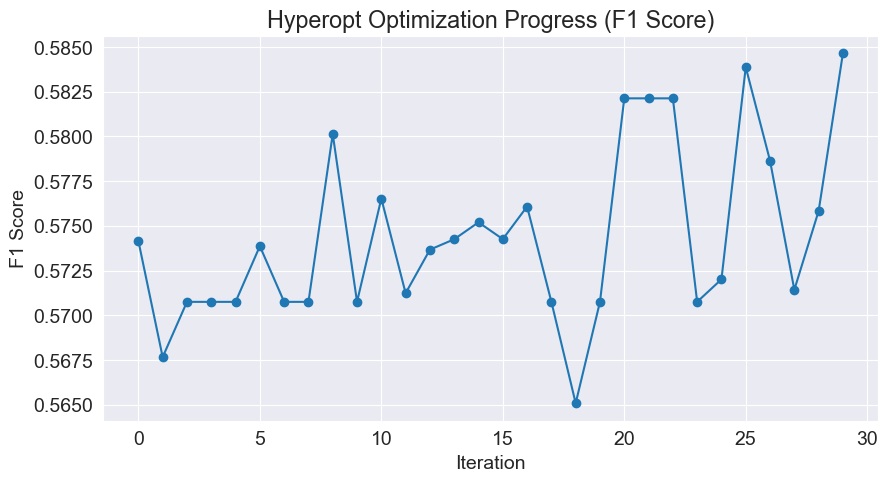

In [30]:
f1_scores_rf = [-t['result']['loss'] for t in trials_rf.trials]

plt.figure(figsize=(10, 5))
plt.plot(f1_scores_rf, marker='o')
plt.title("Hyperopt Optimization Progress (F1 Score)")
plt.xlabel("Iteration")
plt.ylabel("F1 Score")
plt.grid(True)
plt.show()

In [31]:
best_params_rf = space_eval(space_rf, best_rf)
pd.DataFrame(best_params_rf.items(), columns=["Parameter", "Value"])

,Parameter,Value
0,bootstrap,True
1,criterion,entropy
2,max_depth,10.0
3,max_features,sqrt
4,min_samples_leaf,1.0
5,min_samples_split,2.0
6,n_estimators,400.0


In [32]:
best_params_rf['n_estimators'] = int(best_params_rf['n_estimators'])
best_params_rf['max_depth'] = int(best_params_rf['max_depth'])
best_params_rf['min_samples_split'] = int(best_params_rf['min_samples_split'])
best_params_rf['min_samples_leaf'] = int(best_params_rf['min_samples_leaf'])

rf_hp = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        **best_params_rf,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

rf_hp.fit(X_train_classical, y_train_classical)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'previous',
                                                   'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed',
                                                   'campaign_clipped',
                                                   'was_contacted_before',
                                                   'contact_bin', 'month_ord',
                                                   'dow_ord', 'month_euribor3m',
                                                   'month_nr_employed']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  [])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        criterion='entropy', max_depth=10,
                                        n_estimators=400, n_jobs=-1,
                                        random_state=42))])

In [33]:
preds_train_rf_hp = rf_hp.predict(X_train_classical)
preds_val_rf_hp = rf_hp.predict(X_val_classical)
print(classification_report(y_train_classical, preds_train_rf_hp))
print(classification_report(y_val_classical, preds_val_rf_hp))

              precision    recall  f1-score   support

           0       0.96      0.88      0.92     32053
           1       0.37      0.63      0.47      3564

    accuracy                           0.86     35617
   macro avg       0.66      0.75      0.69     35617
weighted avg       0.90      0.86      0.87     35617

              precision    recall  f1-score   support

           0       0.93      0.80      0.86      4495
           1       0.48      0.76      0.58      1076

    accuracy                           0.79      5571
   macro avg       0.70      0.78      0.72      5571
weighted avg       0.84      0.79      0.81      5571



### XGBoost Classifier: Hyperparameter Optimization with Hyperopt

In [34]:
%%time
trials_xgb = Trials()

best_xgb = fmin(fn=objective_xgb, space=space_xgb, algo=tpe.suggest, max_evals=50, trials=trials_xgb);

100%|███████████████████████████████████████████████| 50/50 [00:09<00:00,  5.27trial/s, best loss: -0.5247267048412285]
CPU times: total: 31.5 s
Wall time: 9.5 s


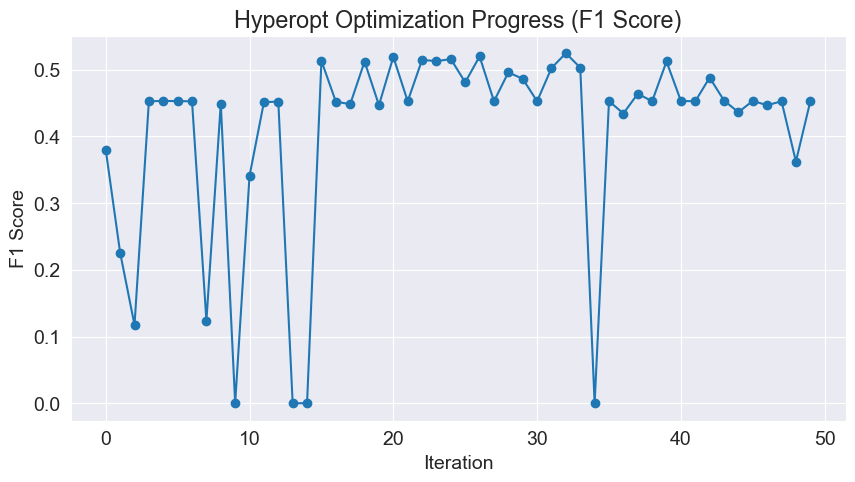

In [35]:
f1_scores = [-t['result']['loss'] for t in trials_xgb.trials]

plt.figure(figsize=(10, 5))
plt.plot(f1_scores, marker='o')
plt.title("Hyperopt Optimization Progress (F1 Score)")
plt.xlabel("Iteration")
plt.ylabel("F1 Score")
plt.grid(True)
plt.show()

In [36]:
best_params_xgb = space_eval(space_xgb, best_xgb)
pd.DataFrame(best_params_xgb.items(), columns=["Parameter", "Value"])

,Parameter,Value
0,colsample_bytree,0.689095
1,gamma,1.682184
2,learning_rate,0.077716
3,max_depth,5.000000
4,min_child_weight,6.000000
5,n_estimators,200.000000
6,reg_alpha,4.225642
7,reg_lambda,5.904094
8,scale_pos_weight,3.500000
9,subsample,0.718299


In [37]:
best_params_xgb['n_estimators'] = int(best_params_xgb['n_estimators'])
best_params_xgb['max_depth'] = int(best_params_xgb['max_depth'])
best_params_xgb['min_child_weight'] = int(best_params_xgb['min_child_weight'])

xgb_hp = xgb.XGBClassifier(
    **best_params_xgb,
    enable_categorical=True,
    eval_metric='logloss',
    missing=np.nan,
    tree_method="hist",
    random_state=42
)

xgb_hp.fit(X_train_bst, y_train_bst);

In [38]:
preds_train_xgb_hp = xgb_hp.predict(X_train_bst)
preds_val_xgb_hp = xgb_hp.predict(X_val_bst)
print(classification_report(y_train_bst, preds_train_xgb_hp))
print(classification_report(y_val_bst, preds_val_xgb_hp))

              precision    recall  f1-score   support

           0       0.95      0.94      0.94     32053
           1       0.49      0.52      0.51      3564

    accuracy                           0.90     35617
   macro avg       0.72      0.73      0.73     35617
weighted avg       0.90      0.90      0.90     35617

              precision    recall  f1-score   support

           0       0.93      0.77      0.85      4495
           1       0.45      0.77      0.57      1076

    accuracy                           0.77      5571
   macro avg       0.69      0.77      0.71      5571
weighted avg       0.84      0.77      0.79      5571



### XGBoost Classifier: Hyperparameter Optimization with RandomSearch

In [39]:
best_params_xgb_rs, best_f1_xgb_rs = random_search_xgb(param_dist=None, n_iter=50)

In [40]:
pd.DataFrame(best_params_xgb_rs.items(), columns=["Parameter", "Value"])

,Parameter,Value
0,n_estimators,231.000000
1,learning_rate,0.015502
2,max_depth,4.000000
3,min_child_weight,7.000000
4,subsample,0.663176
5,colsample_bytree,0.659275
6,gamma,2.827538
7,reg_alpha,4.762789
8,reg_lambda,5.014301
9,scale_pos_weight,3.000000


In [41]:
random_xgb = xgb.XGBClassifier(
    **best_params_xgb_rs,
    enable_categorical=True,
    tree_method="hist",
    missing=np.nan,
    random_state=42
)

random_xgb.fit(X_train_bst, y_train_bst);

In [42]:
preds_train_random_xgb = random_xgb.predict(X_train_bst)
preds_val_random_xgb = random_xgb.predict(X_val_bst)
print(classification_report(y_train_bst, preds_train_random_xgb))
print(classification_report(y_val_bst, preds_val_random_xgb))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94     32053
           1       0.47      0.48      0.47      3564

    accuracy                           0.89     35617
   macro avg       0.71      0.71      0.71     35617
weighted avg       0.89      0.89      0.89     35617

              precision    recall  f1-score   support

           0       0.93      0.79      0.85      4495
           1       0.46      0.76      0.58      1076

    accuracy                           0.78      5571
   macro avg       0.70      0.77      0.71      5571
weighted avg       0.84      0.78      0.80      5571



## Model Evaluation

In [43]:
models_tun = {
    "Logistic Regression": logreg,
    "Decision Tree Grid Search": dt_gs_best,
    "Random Forest Hyperplot": rf_hp,
    "XGBoost Hyperplot": xgb_hp,
    "XGBoost Random Search": random_xgb
}
preds_train_tun = {
    "Logistic Regression": preds_train_logreg,
    "Decision Tree Grid Search": preds_train_dt_gs,
    "Random Forest Hyperplot": preds_train_rf_hp,
    "XGBoost Hyperplot": preds_train_xgb_hp,
    "XGBoost Random Search": preds_train_random_xgb
}
preds_val_tun = {
    "Logistic Regression": preds_val_logreg,
    "Decision Tree Grid Search": preds_val_dt_gs,
    "Random Forest Hyperplot": preds_val_rf_hp,
    "XGBoost Hyperplot": preds_val_xgb_hp,
    "XGBoost Random Search": preds_val_random_xgb
}

In [44]:
df_tun_results = collect_model_results(
    models_tun,
    preds_train_tun,
    preds_val_tun,
    y_train_classical,
    y_val_classical
)

df_tun_results

,Model,F1 (train),F1 (val),Recall (train),Recall (val),Precision (train),Precision (val),Hyperparameters
0,Logistic Regression,0.33,0.57,0.68,0.79,0.22,0.44,"{'C': 0.001,\n 'class_weight': 'balanced',\n 'dual': False,\n 'fit_intercept': True,\n 'intercept_scaling': 1,\n 'l1_ratio': None,\n 'max_iter': 500,\n 'multi_class': 'deprecated',\n 'n_jobs': None,\n 'penalty': 'l2',\n 'random_state': None,\n 'solver': 'liblinear',\n 'tol': 0.0001,\n 'verbose': 0,\n 'warm_start': False}"
1,Decision Tree Grid Search,0.32,0.57,0.69,0.78,0.21,0.45,"{'ccp_alpha': 0.0,\n 'class_weight': 'balanced',\n 'criterion': 'gini',\n 'max_depth': np.int64(4),\n 'max_features': None,\n 'max_leaf_nodes': np.int64(5),\n 'min_impurity_decrease': 0.0,\n 'min_samples_leaf': 1,\n 'min_samples_split': 2,\n 'min_weight_fraction_leaf': 0.0,\n 'monotonic_cst': None,\n 'random_state': 42,\n 'splitter': 'best'}"
2,Random Forest Hyperplot,0.47,0.58,0.63,0.76,0.37,0.48,"{'bootstrap': True,\n 'ccp_alpha': 0.0,\n 'class_weight': 'balanced',\n 'criterion': 'entropy',\n 'max_depth': 10,\n 'max_features': 'sqrt',\n 'max_leaf_nodes': None,\n 'max_samples': None,\n 'min_impurity_decrease': 0.0,\n 'min_samples_leaf': 1,\n 'min_samples_split': 2,\n 'min_weight_fraction_leaf': 0.0,\n 'monotonic_cst': None,\n 'n_estimators': 400,\n 'n_jobs': -1,\n 'oob_score': False,\n 'random_state': 42,\n 'verbose': 0,\n 'warm_start': False}"
3,XGBoost Hyperplot,0.51,0.57,0.52,0.77,0.49,0.45,"{'base_score': None,\n 'booster': None,\n 'callbacks': None,\n 'colsample_bylevel': None,\n 'colsample_bynode': None,\n 'colsample_bytree': 0.6890949649512891,\n 'device': None,\n 'early_stopping_rounds': None,\n 'enable_categorical': True,\n 'eval_metric': 'logloss',\n 'feature_types': None,\n 'feature_weights': None,\n 'gamma': 1.6821835891702113,\n 'grow_policy': None,\n 'importance_type': None,\n 'interaction_constraints': None,\n 'learning_rate': 0.07771562403049477,\n 'max_bin': None,\n 'max_cat_threshold': None,\n 'max_cat_to_onehot': None,\n 'max_delta_step': None,\n 'max_depth': 5,\n 'max_leaves': None,\n 'min_child_weight': 6,\n 'missing': nan,\n 'monotone_constraints': None,\n 'multi_strategy': None,\n 'n_estimators': 200,\n 'n_jobs': None,\n 'num_parallel_tree': None,\n 'objective': 'binary:logistic',\n 'random_state': 42,\n 'reg_alpha': 4.225642498297385,\n 'reg_lambda': 5.9040941108230305,\n 'sampling_method': None,\n 'scale_pos_weight': 3.5,\n 'subsample': 0.7182988371417572,\n 'tree_method': 'hist',\n 'validate_parameters': None,\n 'verbosity': None}"
4,XGBoost Random Search,0.47,0.58,0.48,0.76,0.47,0.46,"{'base_score': None,\n 'booster': None,\n 'callbacks': None,\n 'colsample_bylevel': None,\n 'colsample_bynode': None,\n 'colsample_bytree': 0.6592746225922916,\n 'device': None,\n 'early_stopping_rounds': None,\n 'enable_categorical': True,\n 'eval_metric': None,\n 'feature_types': None,\n 'feature_weights': None,\n 'gamma': 2.8275375949941086,\n 'grow_policy': None,\n 'importance_type': None,\n 'interaction_constraints': None,\n 'learning_rate': 0.015502215594034151,\n 'max_bin': None,\n 'max_cat_threshold': None,\n 'max_cat_to_onehot': None,\n 'max_delta_step': None,\n 'max_depth': 4,\n 'max_leaves': None,\n 'min_child_weight': 7,\n 'missing': nan,\n 'monotone_constraints': None,\n 'multi_strategy': None,\n 'n_estimators': 231,\n 'n_jobs': None,\n 'num_parallel_tree': None,\n 'objective': 'binary:logistic',\n 'random_state': 42,\n 'reg_alpha': 4.762789028735752,\n 'reg_lambda': 5.014301400425393,\n 'sampling_method': None,\n 'scale_pos_weight': 3,\n 'subsample': 0.663176132786537,\n 'tree_method': 'hist',\n 'validate_parameters': None,\n 'verbosity': None}"


## Summary

1. Logistic Regression (Baseline Reference)

2. Decision Tree (After Grid Search)

- After tuning, the Decision Tree matches Logistic Regression, but less stable and more sensitive to data shifts.
- It cannot capture complex interactions as effectively as ensemble methods.

3. Random Forest (After Hyperparameter Tuning)

- Random Forest is more balanced, with higher precision and slightly lower recall, resulting in the highest F1.
- The model benefits from deeper trees (max_depth=10) and class balancing.
- It generalizes well across months and handles nonlinearities effectively.

4. XGBoost (After Hyperplot Tuning)

- XGBoost improves significantly compared to its baseline version.
- Regularization (reg_alpha, reg_lambda) and sampling parameters stabilize the model.
- Still somewhat sensitive to temporal drift, but far less than before tuning.
- Comparable performance, but more complex and less stable than Random Forest.

5. XGBoost (After Random Search Tuning)

- This version of XGBoost performs on par with Random Forest in F1.
- Heavy regularization and moderate depth (max_depth=4) help control overfitting.
- Still more sensitive to macro‑economic shifts than Random Forest.

## Feature importance

In [45]:
rf_preprocess = rf_hp.named_steps["preprocess"]
rf_model = rf_hp.named_steps["model"]
feature_names_rf = rf_preprocess.get_feature_names_out()
importance_rf = rf_model.feature_importances_

importance_df_rf = (
    pd.DataFrame({
        "feature": feature_names_rf,
        "importance": importance_rf
    })
    .sort_values(by="importance", ascending=False)
)

importance_df_rf.head(12)

,feature,importance
12,num__month_euribor3m,0.171449
5,num__euribor3m,0.156965
6,num__nr.employed,0.135187
0,num__age,0.122477
2,num__emp.var.rate,0.075876
7,num__campaign_clipped,0.069082
8,num__was_contacted_before,0.050322
4,num__cons.conf.idx,0.046518
9,num__contact_bin,0.034857
11,num__dow_ord,0.034067


### Interpretation
- RF spreads importance across many features, which is typical for bagged trees.
- It captures broad, stable patterns rather than relying on a few dominant signals.
- Macro‑economic variables matter, but age, campaign, and contact history also play meaningful roles.
- This leads to more stable generalization across months.
### RF behavior summary
- Less sensitive to noise
- Less prone to overfitting
- More robust to temporal drift
- Captures nonlinearities but in a conservative way

In [46]:
importance_xgb = random_xgb.get_booster().get_score(importance_type='gain')

importance_df_xgb = (
    pd.DataFrame({
        'feature': list(importance_xgb.keys()),
        'gain': list(importance_xgb.values())
    })
    .sort_values(by='gain', ascending=False)
)

importance_df_xgb.head(12)

,feature,gain
14,nr.employed,827.243530
10,emp.var.rate,312.018921
12,cons.conf.idx,143.552383
20,month_euribor3m,117.232048
16,was_contacted_before,86.140610
13,euribor3m,64.072708
18,month_ord,56.943401
6,month,51.478828
11,cons.price.idx,38.253777
17,contact_bin,35.478451


### Interpretation
- XGBoost places massive weight on a few macro‑economic variables: ("nr.employed", "emp.var.rate", "cons.conf.idx", "euribor3m")
- These features dominate the model’s decision‑making.
- Behavioral and categorical features matter, but far less than in RF.
- This concentration makes XGB:
- more powerful when the macro‑economic signal is stable
- more fragile when those signals shift (temporal drift)
### XGB behavior summary
- Stronger nonlinear modeling
- More aggressive splits
- Higher variance
- More sensitive to month‑to‑month changes
- Tends to over‑predict positives when macro‑economic indicators shift

### Summary
- Random Forest and XGBoost achieve similar F1 scores after tuning, but they rely on fundamentally different signals. 
- Random Forest distributes importance across macro‑economic, behavioral, and demographic features, resulting in a more stable and balanced model.
- XGBoost concentrates most of its gain on a small set of macro‑economic variables, making it powerful but more sensitive to temporal drift and prone to over‑predicting positives when economic indicators shift.
- This difference in feature reliance explains why Random Forest generalizes more consistently across months, while XGBoost remains more volatile despite tuning.

## SHAP analysis

In [47]:
feature_names_bst = X_val_bst.columns.tolist()
X_val_df_xgb = pd.DataFrame(X_val_bst, columns=feature_names_bst)
explainer_xgb = shap.TreeExplainer(random_xgb)
shap_values_xgb = explainer_xgb.shap_values(X_val_df_xgb)

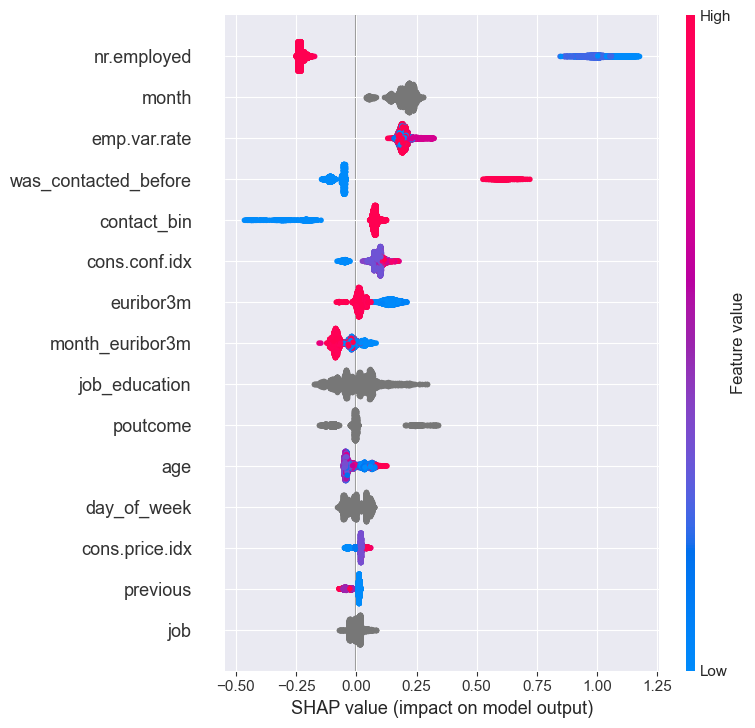

In [48]:
shap.summary_plot(shap_values_xgb, X_val_df_xgb, plot_type="dot", max_display=15)

### Key patterns:
✔ High nr.employed - strong push toward “no”

✔ High emp.var.rate - strong push toward “yes”

✔ Certain months push predictions strongly

✔ Being previously contacted - pushes toward “yes”

✔ Low consumer confidence (cons.conf.idx) - pushes toward “yes”

### Summary
1. XGBoost is highly sensitive to macro‑economic variables
It builds strong, nonlinear interactions on these features.
This explains why XGBoost overfits more than Random Forest.
2. The model predicts “yes” when economic conditions are bad
Low employment, low confidence, low euribor - push toward subscription.
This matches the real behavior of the dataset.
3. Categorical features matter, but less.
They refine predictions but don’t dominate them.

The SHAP results show that XGBoost relies heavily on macro‑economic indicators—especially employment and interest‑rate variables - while behavioral features like previous contact and contact type provide additional lift, making the model powerful but more sensitive to temporal drift than Random Forest.

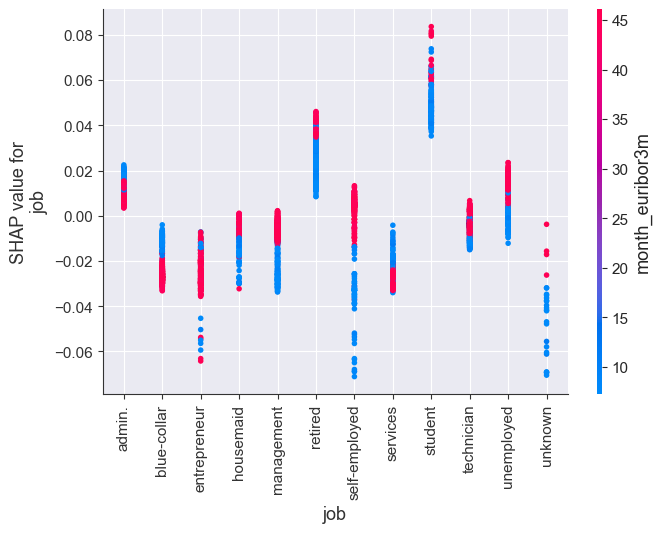

In [49]:
shap.dependence_plot("job", shap_values_xgb, X_val_df_xgb, feature_names=feature_names_bst)

The SHAP dependence plot shows that XGBoost assigns different subscription tendencies to job categories, with students and retirees being more likely to subscribe, blue‑collar and service workers less likely, and these effects are strongly modulated by the prevailing interest‑rate environment (month_euribor3m).

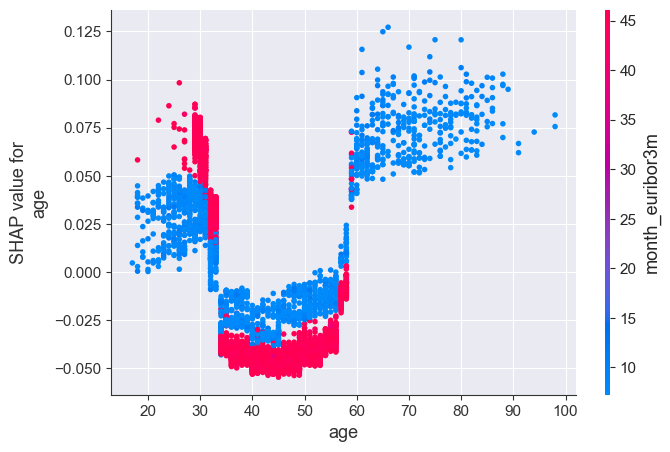

In [50]:
shap.dependence_plot("age", shap_values_xgb, X_val_df_xgb, feature_names=feature_names_bst)

The SHAP dependence plot shows that XGBoost models age in a U‑shaped pattern—young and older customers are more likely to subscribe, middle‑aged customers less, this effect strengthens when interest rates (month_euribor3m) are low.

In [51]:
i = 13

shap.initjs()
shap.force_plot(
    explainer_xgb.expected_value,
    shap_values_xgb[1],
    X_val_df_xgb.iloc[i]
)

For this customer, XGBoost predicts a low probability of subscription because strong negative macro‑economic indicators (high employment and high interest rates) and lack of prior contact outweigh the smaller positive effects of consumer confidence and seasonal timing.

## Misclassification Analysis

In [52]:
confusion_components(y_val_classical, preds_val_rf_hp, model_name="Random Forest (hp)")

Random Forest (hp) – Confusion Components
  TP (correct positives):   815
  TN (correct negatives):   3598
  FP (false positives):     897
  FN (false negatives):     261
  Total samples:            5571
--------------------------------------------------


In [55]:
confusion_components(y_val_bst, preds_val_random_xgb, model_name="XGBoost (random)")

XGBoost (random) – Confusion Components
  TP (correct positives):   820
  TN (correct negatives):   3539
  FP (false positives):     956
  FN (false negatives):     256
  Total samples:            5571
--------------------------------------------------


### Summary
- Random Forest and XGBoost achieve similar overall performance, but they make different types of mistakes. 
- Random Forest is more conservative, producing fewer false positives and therefore more cost‑efficient for marketing.
- XGBoost is more aggressive, identifying slightly more true subscribers but at the cost of a higher false‑positive rate.
- The choice between them depends on whether the business prioritizes precision (minimizing wasted calls - Random Forest) or recall (capturing more potential subscribers - XGBoost).

Misclassification analysis shows that both Random Forest and XGBoost struggle when macro‑economic signals conflict with behavioral or demographic features. To reduce these errors, the model can be improved through advanced feature engineering: adding interaction terms, temporal trend features, richer behavioral history, target encoding for complex categories, customer segmentation, and campaign‑level aggregates. These enhancements help the model better capture nonlinear relationships, temporal drift, and customer engagement patterns, ultimately reducing both false positives and false negatives.

### Conclusion
- The analysis of model performance, misclassifications shows that Random Forest and XGBoost complement each other in meaningful ways.
- Random Forest is stable, conservative, and robust to temporal drift.
  - It produces fewer false positives and relies on a broad set of features, making it reliable for cost‑efficient targeting.
- XGBoost is more expressive and sensitive to nonlinear patterns, especially macro‑economic signals.
  - It captures subtle interactions and achieves slightly higher recall.
- I would use a hybrid approach that combines Random Forest and XGBoost.
- This could be done through: Ensembling (averaging probabilities or weighted voting)
- I think that together, they provide a richer, more complete understanding of the client.